## Original Original - Directly Downloaded

In [57]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

# File pattern (2019 data)
input_pattern = "/l/users/fahad.khan/akhtar/Pangu/data/data_prep/pm-orig/*.nc"

# Load all 2019 surface files
ds_orig_orig = xr.open_mfdataset(sorted(glob.glob(input_pattern)), combine='by_coords')

In [58]:
print(ds_orig_orig['pm2p5'].values.min())

-1.6940658945086007e-21


In [59]:
pm_vars = ['pm1', 'pm2p5', 'pm10']

for var in pm_vars:
    data = ds_orig_orig[var]
    
    # Count number of values below zero
    count_negative = (data < 1e-12).sum().compute().item()
    
    print(f"Number of values < 0 in {var}: {count_negative}")

Number of values < 0 in pm1: 7735570
Number of values < 0 in pm2p5: 6882329
Number of values < 0 in pm10: 6640288


In [60]:
for var in pm_vars:
    data = ds_orig_orig[var]
    
    # Count number of values below zero
    count_negative = (data == 0).sum().compute().item()
    
    print(f"Number of values < 0 in {var}: {count_negative}")

Number of values < 0 in pm1: 4413878
Number of values < 0 in pm2p5: 3350760
Number of values < 0 in pm10: 5097882


## Original PM - Before Merging - After Regridding

In [28]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

# File pattern (2019 data)
input_pattern = "/l/users/fahad.khan/akhtar/Pangu/data/data_prep/pm-processed-orig/*.nc"

# Load all 2019 surface files
ds_orig = xr.open_mfdataset(sorted(glob.glob(input_pattern)), combine='by_coords')

In [30]:
print(ds_orig["pm2p5"].values.min())

-1.6940659e-21


## Before Log Transform

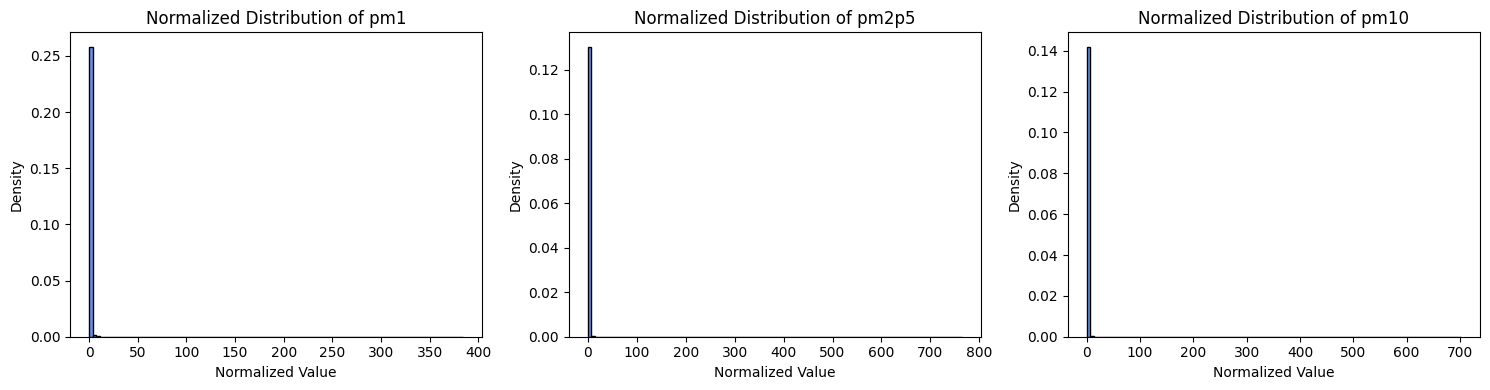

In [48]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

# File pattern (2019 data)
input_pattern = "/l/users/fahad.khan/akhtar/Pangu/data/pangu_data/surface/surface_2019*.nc"

# PM variables and corresponding stats (from your high-precision output)
pm_stats = {
    'pm1':   {'mean': 4.7033090000e-09, 'std': 1.7588029000e-08},
    'pm2p5': {'mean': 1.0949457000e-08, 'std': 2.7642354000e-08},
    'pm10':  {'mean': 1.7928459000e-08, 'std': 4.1681563000e-08},
}

# Load all 2019 surface files
ds = xr.open_mfdataset(sorted(glob.glob(input_pattern)), combine='by_coords')

# Plot setup
plt.figure(figsize=(15, 4))
for i, var in enumerate(pm_stats.keys()):
    data = ds[var].values  # [time, lat, lon]
    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]  # remove NaNs

    # Normalize
    mean = pm_stats[var]['mean']
    std = pm_stats[var]['std']
    normalized = (flat - mean) / std

    # Plot histogram
    plt.subplot(1, 3, i+1)
    plt.hist(normalized, bins=100, color='cornflowerblue', edgecolor='black', density=True)
    plt.title(f"Normalized Distribution of {var}")
    plt.xlabel("Normalized Value")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [49]:
print(ds["pm2p5"].values.min())
print(ds['pm1'].values.min())
print(ds['pm10'].values.min())

-1.6940659e-21
-4.2351647e-22
0.0


## Log Transform - Test 1

Processing: pm1 (scaled log-transformed)


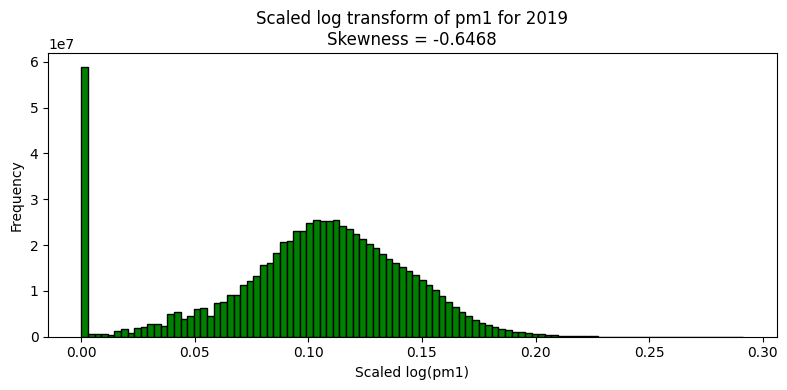

Processing: pm2p5 (scaled log-transformed)


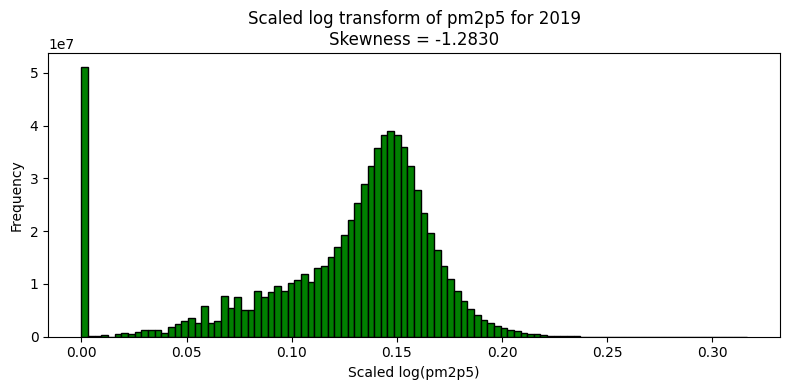

Processing: pm10 (scaled log-transformed)


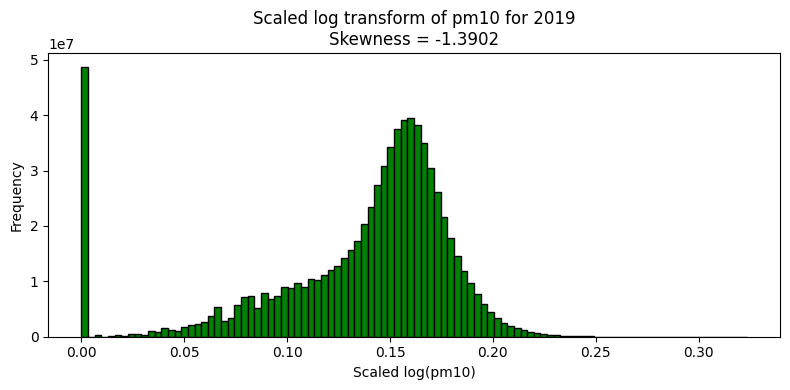

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# PM variables
pm_vars = ['pm1', 'pm2p5', 'pm10']

# Copy dataset
ds_scaled_log = ds.copy()

# Apply scaled log transform to PM variables
for var in pm_vars:
    ds_scaled_log[var] = (np.log(np.maximum(ds[var], 1e-11)) - np.log(1e-11)) / np.log(1e20)

# Plot transformed distributions
for var in pm_vars:
    print(f"Processing: {var} (scaled log-transformed)")
    data = ds_scaled_log[var].values

    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]

    log_skew = skew(flat)

    plt.figure(figsize=(8, 4))
    plt.hist(flat, bins=100, color='green', edgecolor='black')
    plt.title(f"Scaled log transform of {var} for 2019\nSkewness = {log_skew:.4f}")
    plt.xlabel(f"Scaled log({var})")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Normalize After Log Transform

In [55]:
# Dictionary to store mean and std for each variable
mean_std_dict = {}
ds_scaled_log_norm = ds_scaled_log.copy()

# Normalize each scaled log-transformed PM variable
for var in pm_vars:
    print(f"Normalizing: {var} (scaled log-transformed)")

    data = ds_scaled_log[var].values

    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]

    mean_val = flat.mean()
    std_val = flat.std()

    mean_std_dict[var] = (mean_val, std_val)

    # Apply normalization: (x - mean) / std
    ds_scaled_log_norm[var] = (ds_scaled_log[var] - mean_val) / std_val

    print(f"  → Mean = {mean_val:.4f}, Std = {std_val:.4f}")

Normalizing: pm1 (scaled log-transformed)
  → Mean = 0.1006, Std = 0.0440
Normalizing: pm2p5 (scaled log-transformed)
  → Mean = 0.1249, Std = 0.0466
Normalizing: pm10 (scaled log-transformed)
  → Mean = 0.1351, Std = 0.0486


Processing: pm1 (scaled log-transformed)


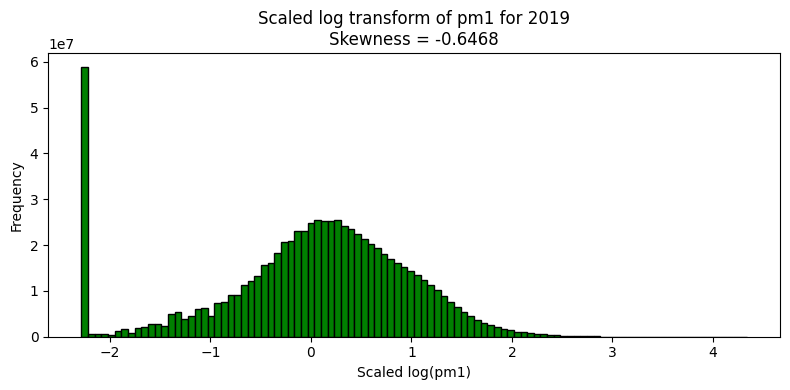

Processing: pm2p5 (scaled log-transformed)


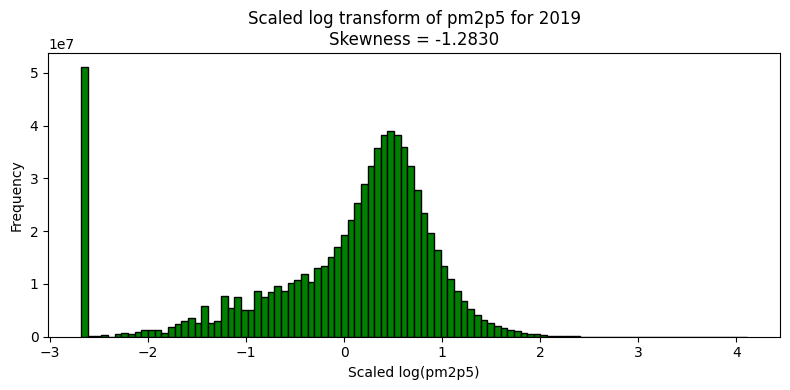

Processing: pm10 (scaled log-transformed)


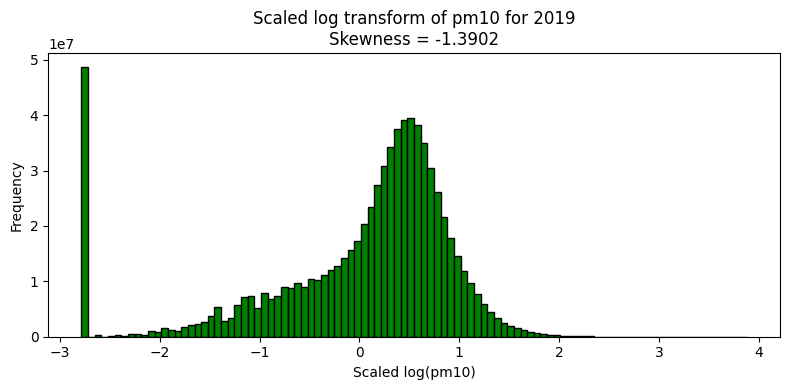

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# PM variables
pm_vars = ['pm1', 'pm2p5', 'pm10']

# Plot transformed distributions
for var in pm_vars:
    print(f"Processing: {var} (scaled log-transformed)")
    data = ds_scaled_log_norm[var].values

    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]

    log_skew = skew(flat)

    plt.figure(figsize=(8, 4))
    plt.hist(flat, bins=100, color='green', edgecolor='black')
    plt.title(f"Scaled log transform of {var} for 2019\nSkewness = {log_skew:.4f}")
    plt.xlabel(f"Scaled log({var})")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Log Transform - Test 2


Processing: pm1 (scaled log-transformed)


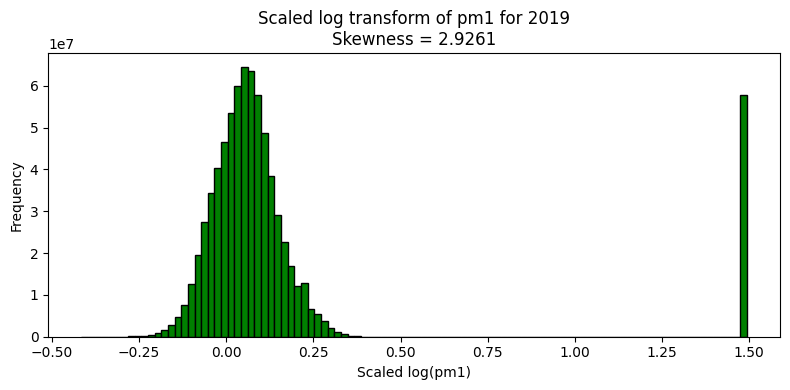

Processing: pm2p5 (scaled log-transformed)


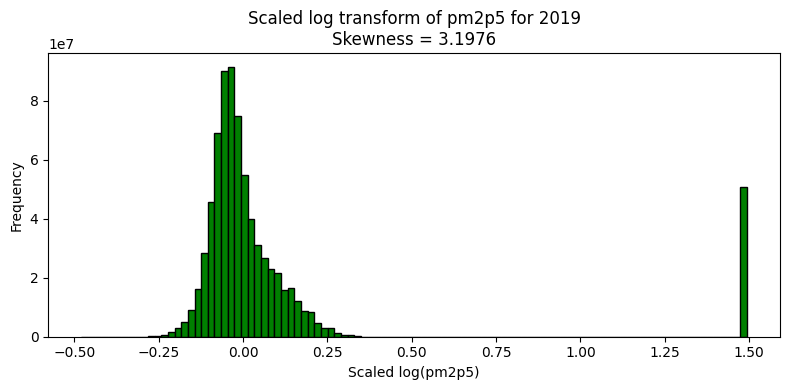

Processing: pm10 (scaled log-transformed)


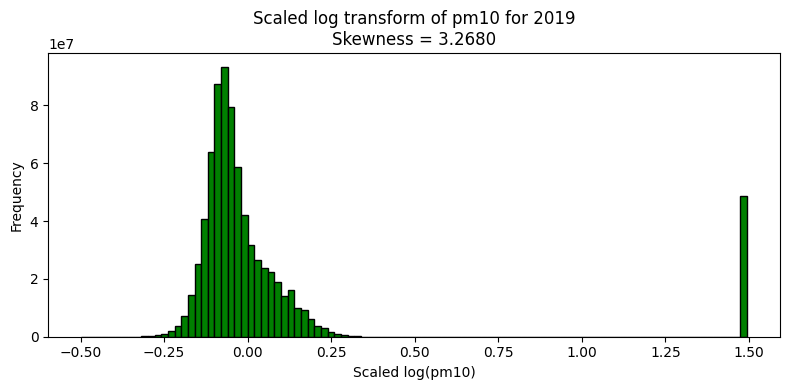

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# PM variables
pm_vars = ['pm1', 'pm2p5', 'pm10']

# Copy dataset
ds_scaled_log = ds.copy()

# Apply scaled log transform to PM variables
for var in pm_vars:
    ds_scaled_log[var] = (np.log(np.maximum(ds[var], 1e-20)) - np.log(4e-9)) / np.log(1.7e-8)

# Plot transformed distributions
for var in pm_vars:
    print(f"Processing: {var} (scaled log-transformed)")
    data = ds_scaled_log[var].values

    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]

    log_skew = skew(flat)

    plt.figure(figsize=(8, 4))
    plt.hist(flat, bins=100, color='green', edgecolor='black')
    plt.title(f"Scaled log transform of {var} for 2019\nSkewness = {log_skew:.4f}")
    plt.xlabel(f"Scaled log({var})")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

Processing: pm1 (scaled log-transformed)


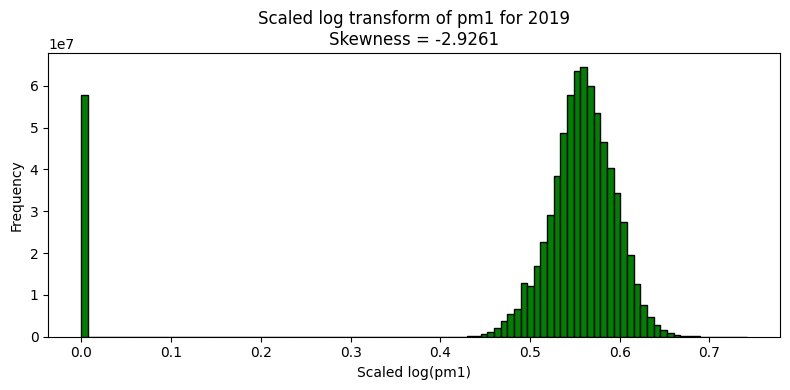

Processing: pm2p5 (scaled log-transformed)


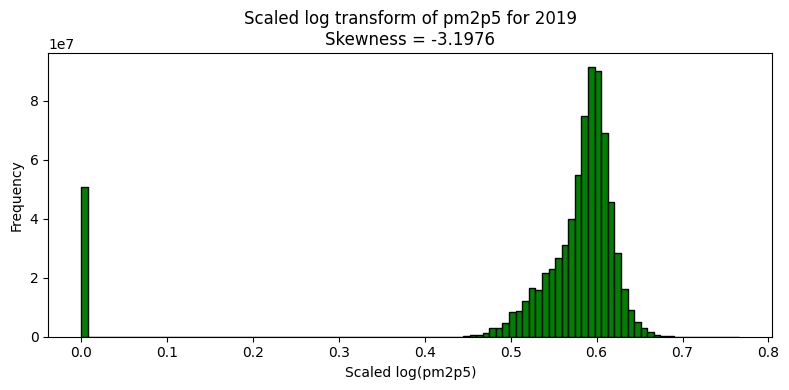

Processing: pm10 (scaled log-transformed)


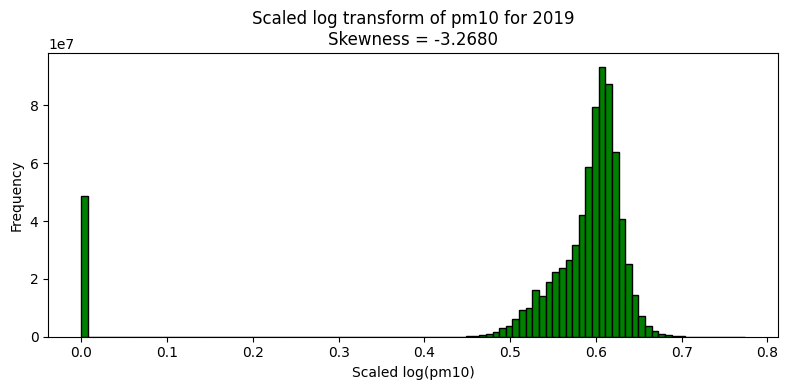

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# PM variables
pm_vars = ['pm1', 'pm2p5', 'pm10']

# Copy dataset
ds_scaled_log = ds.copy()

# Apply scaled log transform to PM variables
for var in pm_vars:
    ds_scaled_log[var] = (np.log(np.maximum(ds[var], 1e-20)) - np.log(1e-20)) / np.log(1e20)

# Plot transformed distributions
for var in pm_vars:
    print(f"Processing: {var} (scaled log-transformed)")
    data = ds_scaled_log[var].values

    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]

    log_skew = skew(flat)

    plt.figure(figsize=(8, 4))
    plt.hist(flat, bins=100, color='green', edgecolor='black')
    plt.title(f"Scaled log transform of {var} for 2019\nSkewness = {log_skew:.4f}")
    plt.xlabel(f"Scaled log({var})")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [21]:
print(ds_scaled_log['pm2p5'].values.min())


-1.3886755766000065e-08
